In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import perf_counter
import numpy as np

In [27]:
def baseline_max_sublist(arr):
    """
    Naive baseline algorithm for maximum subarray.
    Tries all contiguous subarrays using nested loops.
    Time complexity: O(n^2).
    """
    max_sum = float('-inf')
    n = len(arr)

    for start in range(n):
        current_sum = 0
        for end in range(start, n):
            current_sum += arr[end]
            if current_sum > max_sum:
                max_sum = current_sum

    return max_sum

In [28]:
def kadane_max_sublist(arr):
    """
    Kadane's algorithm for maximum subarray.
    Uses a running sum and resets when it goes negative.
    Time complexity: O(n).
    """
    max_so_far = float('-inf')
    current_max = 0

    for x in arr:
        current_max += x

        if current_max > max_so_far:
            max_so_far = current_max

        if current_max < 0:
            current_max = 0

    return max_so_far

In [29]:
def generate_list(n, low=-100, high=100):
    """
    Generate a list of n random integers
    between low and high (inclusive).
    """
    return np.random.randint(low, high + 1, size=n)

In [30]:
def benchmark(func, sizes, runs=5):
    """
    Benchmark a function over different input sizes.
    Returns a list of average times.
    """
    avg_times = []

    for n in sizes:
        times = []
        for _ in range(runs):
            arr = generate_list(n)
            start = perf_counter()
            func(arr)
            end = perf_counter()
            times.append(end - start)
        avg_times.append(sum(times) / len(times))

    return avg_times

In [31]:
sizes = [100, 500, 1000, 2500, 5000, 10000]

baseline_times = benchmark(baseline_max_sublist, sizes, runs=7)
kadane_times = benchmark(kadane_max_sublist, sizes, runs=7)

baseline_times, kadane_times

([0.0004622320006352051,
  0.009210809428103468,
  0.04085902356954258,
  0.24659629157187218,
  0.967983345142524,
  3.7070578095715194],
 [1.3791573499994619e-05,
  4.272014068971787e-05,
  8.483928520165916e-05,
  0.00020832756958303174,
  0.00041939285750101717,
  0.0008399941445012311])

In [32]:
results_df = pd.DataFrame({
    "n": sizes,
    "baseline_time": baseline_times,
    "kadane_time": kadane_times
})

results_df

,n,baseline_time,kadane_time
0,100,0.000462,0.000014
1,500,0.009211,0.000043
2,1000,0.040859,0.000085
3,2500,0.246596,0.000208
4,5000,0.967983,0.000419
5,10000,3.707058,0.000840


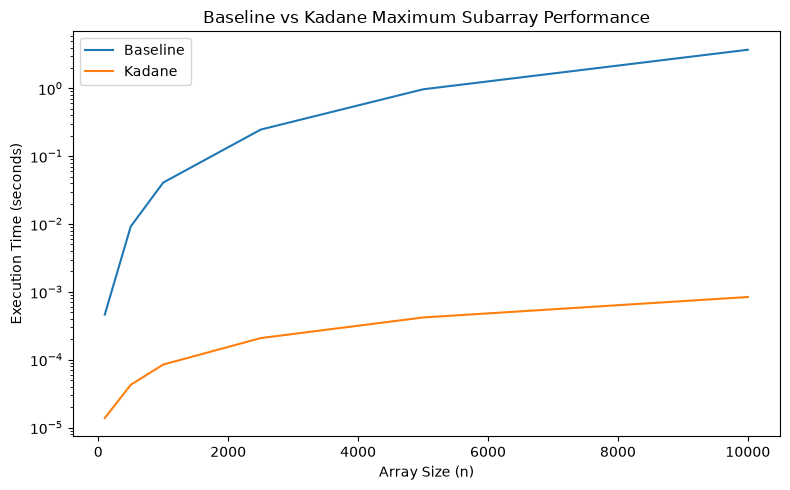

In [33]:
plt.figure(figsize=(8, 5))
sns.lineplot(x="n", y="baseline_time", data=results_df, label="Baseline")
sns.lineplot(x="n", y="kadane_time", data=results_df, label="Kadane")

plt.xlabel("Array Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Baseline vs Kadane Maximum Subarray Performance")
plt.legend()
plt.yscale("log")  # optional but recommended
plt.tight_layout()
plt.show()